# Learning Images as Implicit Functions

An image is usually stored as a grid of pixels. This notebook explores a different representation:
train a small neural network $f_\theta$ that maps **continuous pixel coordinates to colours**,

$$f_\theta : (x, y) \in [-1, 1]^2 \;\longmapsto\; (R, G, B) \in [0, 1]^3,$$

so that the network *is* the image. This is called an **implicit neural representation** (INR), or a
*coordinate network*: the signal is defined implicitly as the output of a function, rather than
explicitly as a table of samples.

Why bother? Two properties fall out of the functional view:

1. **The representation is continuous.** A pixel grid only defines the image at integer locations;
   $f_\theta$ can be evaluated *anywhere*, so a single trained network can be rendered at any
   resolution — the application we demonstrate at the end (upscaling).
2. **The representation is compact and differentiable.** The "image" is now a vector of weights that
   can be optimized, regularized, or queried for gradients. This is the machinery behind DeepSDF
   [6] and Occupancy Networks [7] for 3D shapes, and most famously NeRF [4], which represents an
   entire 3D scene as a coordinate network $(x, y, z, \theta, \phi) \mapsto (\text{colour}, \text{density})$.
   (Coordinate-to-colour networks are older than the current wave — CPPNs [8] used the same idea in
   2007 for evolving patterns.)

There is a catch, though, and it makes for a nice story in three acts:

- **Act 1** — a plain ReLU MLP on raw $(x, y)$ fails, producing a blurry image. This is the
  *spectral bias* of neural networks [3].
- **Act 2** — two classic fixes: **random Fourier features** [2] and **SIREN**'s sine activations
  [1] let the same small MLP fit the image sharply.
- **Act 3** — the payoff: train on a low-resolution image, then sample the continuous function on a
  finer grid to **upscale at arbitrary (even non-integer) scale factors**, compared honestly
  against bicubic interpolation.

Numbered citations refer to the [References](#References) at the bottom. All the model/training code
lives in [`../src/`](../src/) — the notebook only orchestrates it. Everything runs on CPU in a few
minutes.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

sys.path.insert(0, str(Path.cwd().parent))

from src import (
    FourierFeatureMLP,
    ReluMLP,
    Siren,
    downsample,
    fit,
    load_image,
    make_coordinate_grid,
    psnr,
    render,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUTS = Path.cwd().parent / "outputs"
OUTPUTS.mkdir(exist_ok=True)
print(f"torch {torch.__version__}, device: {device}")

torch 2.12.1+cu130, device: cpu


## The data: one image, treated as a supervised dataset

We use `kodim19` ("lighthouse") from the [Kodak Lossless True Color Image
Suite](https://r0k.us/graphics/kodak/), a standard test set in the image-processing literature,
downsampled to $384 \times 256$ to keep things CPU-friendly.

The picket fence and the lighthouse railing are full of high-frequency detail — exactly the content
that will separate the models in Acts 1 and 2.

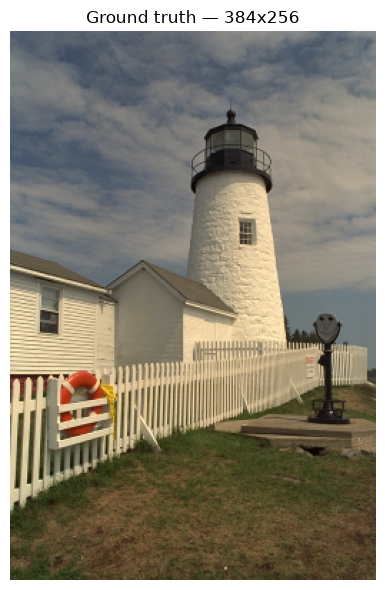

In [2]:
image = load_image(Path.cwd().parent / "data" / "lighthouse.png")

fig, ax = plt.subplots(figsize=(4, 6))
ax.imshow(image)
ax.set_title(f"Ground truth — {image.shape[0]}x{image.shape[1]}")
ax.axis("off")
plt.tight_layout()
plt.show()

### From image to (coordinates, colours) pairs

Fitting an INR is ordinary supervised regression. The training set is the image itself: one sample
per pixel, with the pixel-centre coordinate as input and the RGB value as target,

$$\mathcal{D} = \big\{ \big( (x_i, y_i),\; c_i \big) \big\}_{i=1}^{H \cdot W},
\qquad \text{minimise} \quad \mathcal{L}(\theta) = \frac{1}{HW} \sum_i \lVert f_\theta(x_i, y_i) - c_i \rVert_2^2 .$$

Coordinates are normalized to $[-1, 1]^2$ using **pixel centres** (a half-pixel offset), so grids of
different resolutions sample the same continuous domain consistently — this detail is what makes
"render the same network at a new resolution" geometrically meaningful later.

For the model comparison we fit a $192 \times 128$ version of the image (24{,}576 pixels), trained
**full-batch**: at this size the whole dataset fits in one gradient step, which is both the simplest
and the fastest option.

In [3]:
comparison_target = downsample(image, 2)  # 192x128
h, w, _ = comparison_target.shape

coords = make_coordinate_grid(h, w, device=device)
targets = torch.from_numpy(comparison_target).reshape(-1, 3).to(device)
print(
    f"training set: {coords.shape[0]} pixels, coords {tuple(coords.shape)} -> targets {tuple(targets.shape)}"
)

training set: 24576 pixels, coords (24576, 2) -> targets (24576, 3)


## Act 1 — the naive attempt: a ReLU MLP on raw coordinates

The obvious first model is a small MLP: $(x, y)$ in, three hidden ReLU layers of width 128, RGB out.
It has plenty of capacity for a 24k-pixel image, and it will still fail in a characteristic way.

The reason is **spectral bias** [3]: neural networks trained by gradient descent learn low
frequencies first, and for a low-dimensional input like $(x,y)$ the high frequencies arrive so
slowly that they effectively never come. In the language of the neural tangent kernel, the kernel
eigenvalues corresponding to high-frequency components are tiny, so those components converge at a
correspondingly tiny rate [2]. The result: sky and lawn are fine, and the picket fence dissolves
into mush.

In [4]:
STEPS = 1000
HIDDEN, LAYERS = 128, 3

torch.manual_seed(0)
relu_model = ReluMLP(hidden_features=HIDDEN, hidden_layers=LAYERS).to(device)

start = time.time()
relu_result = fit(relu_model, coords, targets, steps=STEPS, lr=1e-3)
relu_recon = render(relu_model, h, w)
print(
    f"ReLU MLP: {psnr(relu_recon, comparison_target):.2f} dB PSNR ({time.time() - start:.0f}s)"
)

ReLU MLP: 21.59 dB PSNR (109s)


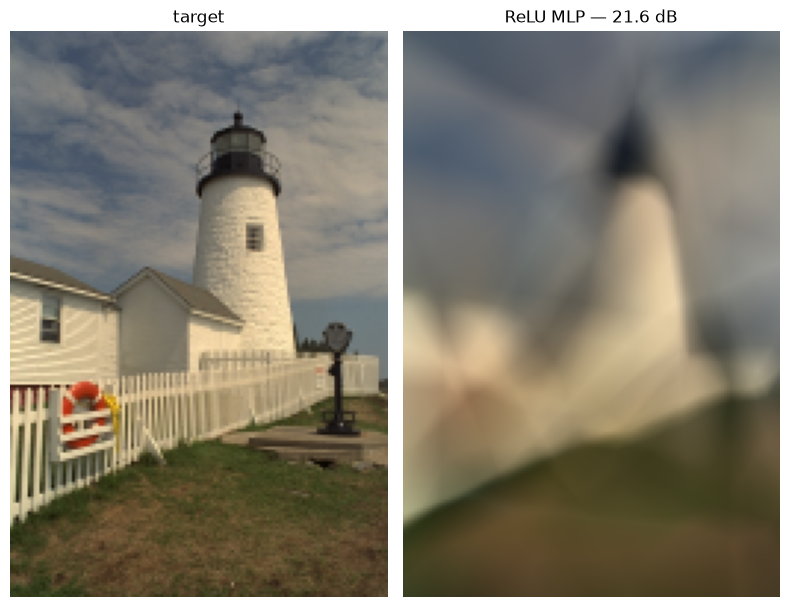

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))
axes[0].imshow(comparison_target)
axes[0].set_title("target")
axes[1].imshow(relu_recon)
axes[1].set_title(f"ReLU MLP — {psnr(relu_recon, comparison_target):.1f} dB")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

~20 dB and visibly blurry, as promised. Note this is *not* underfitting in the usual sense — more
steps barely help, because the missing frequencies converge exponentially slower than the ones
already there [2, 3].

## Act 2, fix #1 — random Fourier features

Tancik et al. [2] showed that the problem is the *input parametrization*, not the MLP. Lift the
coordinates through a random **Fourier feature mapping**

$$\gamma(\mathbf{v}) = \big[ \sin(2\pi B\mathbf{v}),\; \cos(2\pi B\mathbf{v}) \big],
\qquad B \in \mathbb{R}^{m \times 2},\; B_{ij} \sim \mathcal{N}(0, \sigma^2),$$

and feed $\gamma(x, y)$ to the very same ReLU MLP. In NTK terms the mapping turns the network's
kernel into a *stationary* one whose bandwidth is set by $\sigma$: the network becomes equally
willing to learn all frequencies up to that bandwidth. ($\sigma$ is the one knob — too small and the
result is still blurry, too large and the network overfits noise between pixels; $\sigma = 10$ works
well at this resolution.)

In [6]:
torch.manual_seed(0)
fourier_model = FourierFeatureMLP(
    hidden_features=HIDDEN, hidden_layers=LAYERS, mapping_size=128, sigma=10.0
).to(device)

start = time.time()
fourier_result = fit(fourier_model, coords, targets, steps=STEPS, lr=1e-3)
fourier_recon = render(fourier_model, h, w)
print(
    f"Fourier features: {psnr(fourier_recon, comparison_target):.2f} dB PSNR ({time.time() - start:.0f}s)"
)

Fourier features: 36.25 dB PSNR (57s)


## Act 2, fix #2 — SIREN: sine activations

SIREN [1] attacks the same problem from inside the network: replace every ReLU with a **sine**,

$$\mathbf{h}_{l+1} = \sin\!\big( \omega_0\, W_l \mathbf{h}_l + \mathbf{b}_l \big),$$

with two crucial details from the paper: a frequency scale $\omega_0 = 30$, and a uniform weight
initialisation $W \sim \mathcal{U}\!\big(-\sqrt{6/\text{fan\_in}}/\omega_0,\; \sqrt{6/\text{fan\_in}}/\omega_0\big)$
chosen so that pre-activations stay well-distributed through depth and deep sine stacks train
stably. Sine activations make the network an adjustable composition of waves — high frequencies are
available from step one, and (a bonus we don't use here) $f_\theta$ is infinitely differentiable,
which is why SIRENs can be supervised through their *derivatives* (fitting gradients, solving PDEs
and wave equations) [1].

In [7]:
torch.manual_seed(0)
siren_model = Siren(hidden_features=HIDDEN, hidden_layers=LAYERS).to(device)

start = time.time()
siren_result = fit(siren_model, coords, targets, steps=STEPS, lr=1e-3)
siren_recon = render(siren_model, h, w)
print(
    f"SIREN: {psnr(siren_recon, comparison_target):.2f} dB PSNR ({time.time() - start:.0f}s)"
)

SIREN: 38.16 dB PSNR (119s)


### Side by side

Same MLP size, same optimizer, same 1000 steps — the only difference is how coordinates enter the
network.

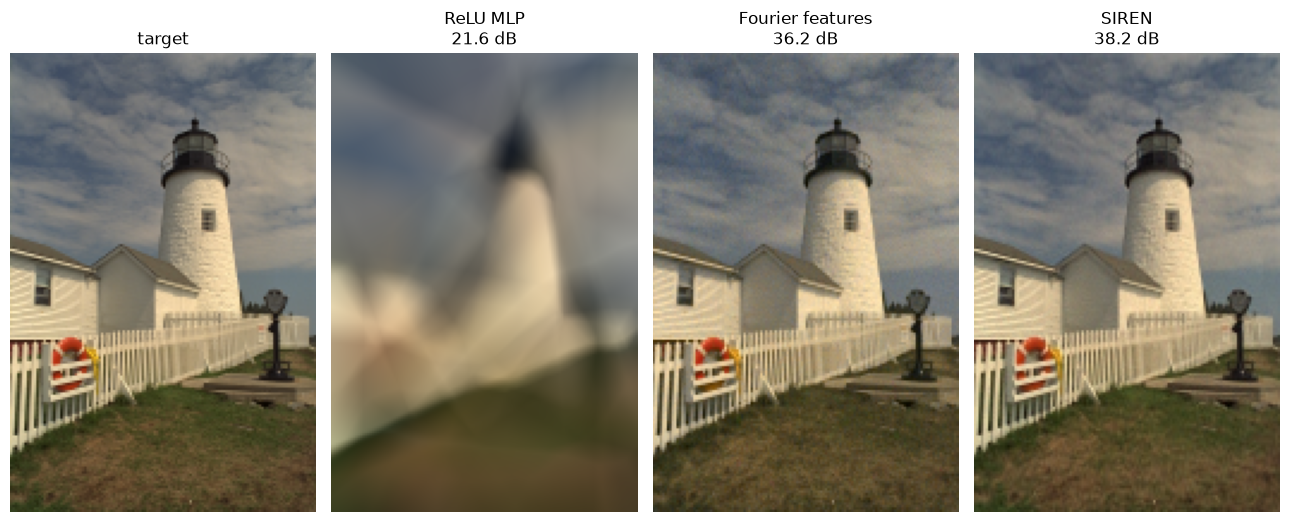

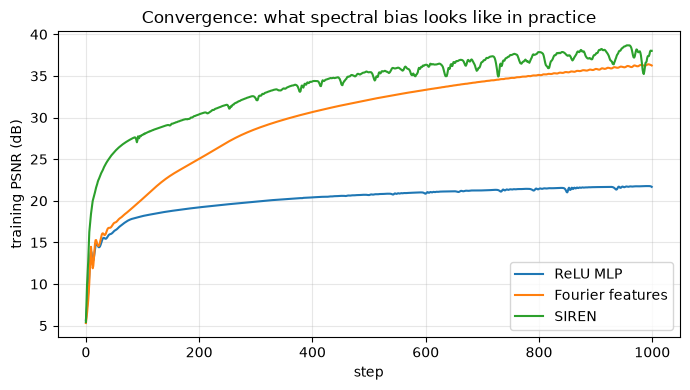

In [8]:
reconstructions = [
    ("target", comparison_target, None),
    ("ReLU MLP", relu_recon, relu_result),
    ("Fourier features", fourier_recon, fourier_result),
    ("SIREN", siren_recon, siren_result),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 5.2))
for ax, (name, img, _) in zip(axes, reconstructions):
    ax.imshow(img)
    title = (
        name if name == "target" else f"{name}\n{psnr(img, comparison_target):.1f} dB"
    )
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUTS / "reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for name, _, result in reconstructions[1:]:
    ax.plot(result.psnrs, label=name)
ax.set_xlabel("step")
ax.set_ylabel("training PSNR (dB)")
ax.set_title("Convergence: what spectral bias looks like in practice")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

The training curves are the quantitative version of the story: the ReLU MLP plateaus almost
immediately (its remaining error lives in frequencies it learns exponentially slowly), while the
Fourier-feature MLP and SIREN keep climbing well past it.

## Act 3 — the application: arbitrary-scale upscaling

Here is the property that makes INRs more than a curiosity. The trained network is a **continuous
function**: nothing about $f_\theta$ knows or cares about the training grid. So we can

1. train on a **low-resolution** image ($96 \times 64$ — a 4× downsample), and
2. render the learned function on **any** grid we like — $4\times$, $2.5\times$, whatever —
   just by evaluating it at more coordinates.

This "train once, decode at any resolution" mechanism is exactly what learned super-resolution
methods like LIIF [5] build on.

**An honest caveat before the pictures**: a network fitted to a *single* low-resolution image has
seen no information beyond those $96 \times 64$ pixels, so it cannot invent the true high-frequency
detail — no single-image method can. Expect it to land in the same quality range as bicubic
interpolation, not above it. What lifts methods like LIIF past bicubic is a *learned prior*: an
encoder trained across thousands of images that predicts plausible local detail. What this demo
isolates is the representation mechanism those methods share — one compact network, decoded at any
scale.

In [9]:
low_res = downsample(image, 4)  # 96x64
lh, lw, _ = low_res.shape
gt_h, gt_w, _ = image.shape

low_coords = make_coordinate_grid(lh, lw, device=device)
low_targets = torch.from_numpy(low_res).reshape(-1, 3).to(device)

torch.manual_seed(0)
sr_model = Siren(hidden_features=HIDDEN, hidden_layers=LAYERS).to(device)
start = time.time()
sr_result = fit(sr_model, low_coords, low_targets, steps=2000, lr=1e-3)
print(
    f"fit SIREN on {lh}x{lw}: {sr_result.final_psnr:.2f} dB train PSNR "
    f"({time.time() - start:.0f}s)"
)

# The same weights, sampled on a 4x finer grid:
inr_4x = render(sr_model, gt_h, gt_w)

# Classical baseline: bicubic interpolation to the same size.
low_tensor = torch.from_numpy(low_res).permute(2, 0, 1).unsqueeze(0)
bicubic_4x = (
    F.interpolate(low_tensor, size=(gt_h, gt_w), mode="bicubic", align_corners=False)
    .squeeze(0)
    .permute(1, 2, 0)
    .clamp(0, 1)
    .numpy()
    .astype(np.float32)
)

print(f"INR 4x:     {psnr(inr_4x, image):.2f} dB vs ground truth")
print(f"bicubic 4x: {psnr(bicubic_4x, image):.2f} dB vs ground truth")

fit SIREN on 96x64: 56.66 dB train PSNR (68s)


INR 4x:     23.43 dB vs ground truth
bicubic 4x: 23.53 dB vs ground truth


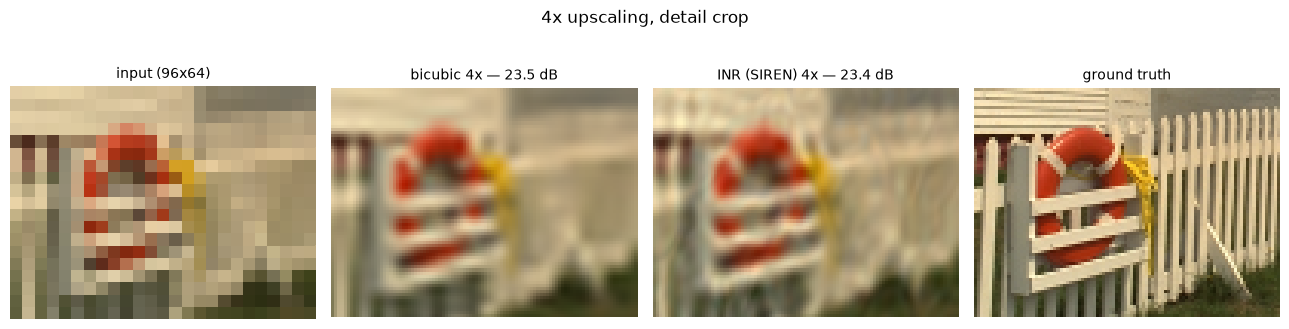

In [10]:
def crop(img, factor=1):
    top, bottom, left, right = 225, 300, 15, 115  # picket fence + life ring
    return img[top // factor : bottom // factor, left // factor : right // factor]


panels = [
    (f"input ({lh}x{lw})", crop(low_res, factor=4)),
    (f"bicubic 4x — {psnr(bicubic_4x, image):.1f} dB", crop(bicubic_4x)),
    (f"INR (SIREN) 4x — {psnr(inr_4x, image):.1f} dB", crop(inr_4x)),
    ("ground truth", crop(image)),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (name, img) in zip(axes, panels):
    ax.imshow(img, interpolation="nearest")
    ax.set_title(name, fontsize=10)
    ax.axis("off")
fig.suptitle("4x upscaling, detail crop", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS / "upscaling_crops.png", dpi=150, bbox_inches="tight")
plt.show()

As predicted, the INR and bicubic land within a fraction of a dB of each other — both are smooth
interpolants of the same 6k pixels, and neither can restore the fence slats that the 4× downsample
destroyed. The point of the demo is *how* the INR version got there: bicubic is a fixed formula tied
to the source grid, while the INR is a resolution-free function of which the $4\times$ grid is just
one possible sampling.

To drive that home, render the same weights at a **non-integer** scale — something a pixel-grid
pipeline needs special-case resampling for, and a coordinate network does natively:

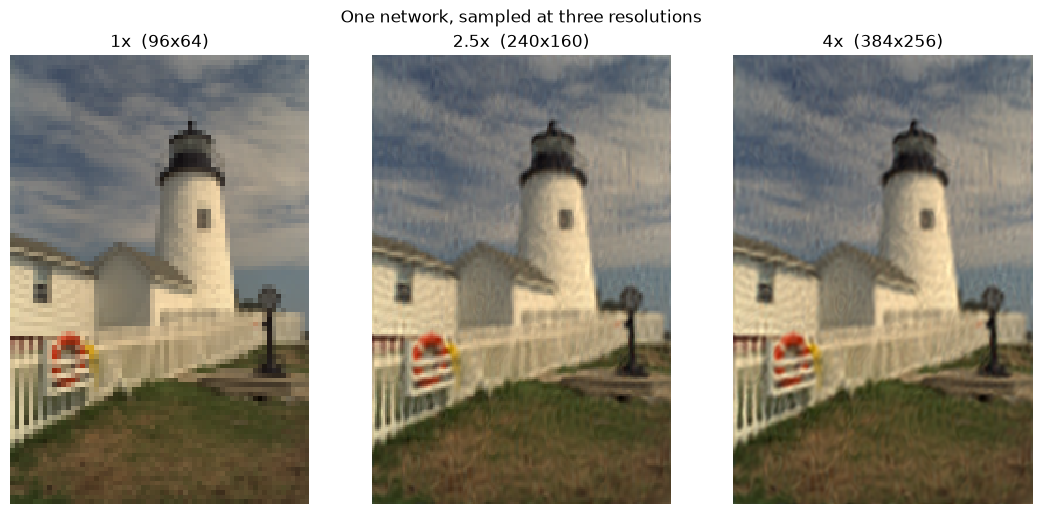

In [11]:
scales = [1.0, 2.5, 4.0]
fig, axes = plt.subplots(1, len(scales), figsize=(11, 5.2))
for ax, s in zip(axes, scales):
    rendered = render(sr_model, int(lh * s), int(lw * s))
    ax.imshow(rendered, interpolation="nearest")
    ax.set_title(f"{s:g}x  ({int(lh * s)}x{int(lw * s)})")
    ax.axis("off")
fig.suptitle("One network, sampled at three resolutions", y=0.98)
plt.tight_layout()
plt.savefig(OUTPUTS / "arbitrary_scale.png", dpi=150, bbox_inches="tight")
plt.show()

## Where this goes

Everything above generalizes far beyond one photo of a lighthouse. The same recipe — coordinates in,
signal out, spectral-bias fix in between — is the backbone of:

- **3D shape and scene representation**: signed distance functions (DeepSDF [6]), occupancy fields
  [7], and radiance fields (NeRF [4]), where the "image" is a 3D scene and the "pixels" are camera
  rays.
- **Learned super-resolution**: LIIF [5] conditions a local INR on features from an encoder trained
  across a large image corpus — the continuous-decoding mechanism from Act 3 plus a learned prior,
  which is what finally beats bicubic.
- **Compression**: the SR network above has ~50k parameters and reproduces the image it was trained
  on — weights-as-image is an actively studied compression scheme.
- **Physics**: because $f_\theta$ is differentiable, SIRENs can be trained through $\nabla f$ or
  $\Delta f$, i.e. fitted to gradients or used to solve PDEs [1].

Things worth trying in this notebook: sweep the Fourier-feature bandwidth $\sigma$ and watch the
blur/noise trade-off [2]; drop $\omega_0$ to 5 and watch SIREN reproduce the ReLU failure; fit the
full-resolution image with a bigger network; or supervise a SIREN on image *gradients* instead of
colours (Sec. 4.1 of [1]).

## References

1. Sitzmann, V., Martel, J. N. P., Bergman, A. W., Lindell, D. B., Wetzstein, G. (2020).
   *Implicit Neural Representations with Periodic Activation Functions* (SIREN). NeurIPS 2020.
   [arXiv:2006.09661](https://arxiv.org/abs/2006.09661)
2. Tancik, M., Srinivasan, P. P., Mildenhall, B., Fridovich-Keil, S., Raghavan, N., Singhal, U.,
   Ramamoorthi, R., Barron, J. T., Ng, R. (2020). *Fourier Features Let Networks Learn High
   Frequency Functions in Low Dimensional Domains*. NeurIPS 2020.
   [arXiv:2006.10739](https://arxiv.org/abs/2006.10739)
3. Rahaman, N., Baratin, A., Arpit, D., Draxler, F., Lin, M., Hamprecht, F. A., Bengio, Y.,
   Courville, A. (2019). *On the Spectral Bias of Neural Networks*. ICML 2019.
   [arXiv:1806.08734](https://arxiv.org/abs/1806.08734)
4. Mildenhall, B., Srinivasan, P. P., Tancik, M., Barron, J. T., Ramamoorthi, R., Ng, R. (2020).
   *NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis*. ECCV 2020.
   [arXiv:2003.08934](https://arxiv.org/abs/2003.08934)
5. Chen, Y., Liu, S., Wang, X. (2021). *Learning Continuous Image Representation with Local
   Implicit Image Function* (LIIF). CVPR 2021.
   [arXiv:2012.09161](https://arxiv.org/abs/2012.09161)
6. Park, J. J., Florence, P., Straub, J., Newcombe, R., Lovegrove, S. (2019). *DeepSDF: Learning
   Continuous Signed Distance Functions for Shape Representation*. CVPR 2019.
   [arXiv:1901.05103](https://arxiv.org/abs/1901.05103)
7. Mescheder, L., Oechsle, M., Niemeyer, M., Nowozin, S., Geiger, A. (2019). *Occupancy Networks:
   Learning 3D Reconstruction in Function Space*. CVPR 2019.
   [arXiv:1812.03828](https://arxiv.org/abs/1812.03828)
8. Stanley, K. O. (2007). *Compositional Pattern Producing Networks: A Novel Abstraction of
   Development*. Genetic Programming and Evolvable Machines, 8(2), 131-162.

Sample image: `kodim19` from the [Kodak Lossless True Color Image Suite](https://r0k.us/graphics/kodak/),
released by Kodak for unrestricted use.